# Dynamic Prediction System: For AirBnb's 

This model will be trained on the data taken from kaggle, the data chosen is of USA, and based on the all the training of the data with various model and predictions the best model to perform will be used to give an output which can help the host to select the best price range for their listing, based on the Location and many other factors.

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.preprocessing import StandardScaler
from warnings import filterwarnings
filterwarnings('ignore')

In [119]:
Dataset = pd.read_csv('Data/Data.csv')

In [120]:
Dataset.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,38585,Charming Victorian home - twin beds + breakfast,165529,Evelyne,NaN,28804,35.65146,-82.62792,Private room,60,1,138,16/02/20,1.14,1,0,Asheville
1,80905,French Chic Loft,427027,Celeste,NaN,28801,35.59779,-82.55540,Entire home/apt,470,1,114,07/09/20,1.03,11,288,Asheville
2,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,320564,Lisa,NaN,28801,35.60670,-82.55563,Entire home/apt,75,30,89,30/11/19,0.81,2,298,Asheville
3,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.57864,-82.59578,Entire home/apt,90,1,267,22/09/20,2.39,5,0,Asheville
4,160594,Historic Grove Park,769252,Elizabeth,NaN,28801,35.61442,-82.54127,Private room,125,30,58,19/10/15,0.52,1,0,Asheville


In [121]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226030 entries, 0 to 226029
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              226030 non-null  int64  
 1   name                            226002 non-null  object 
 2   host_id                         226030 non-null  int64  
 3   host_name                       225997 non-null  object 
 4   neighbourhood_group             110185 non-null  object 
 5   neighbourhood                   226030 non-null  object 
 6   latitude                        226030 non-null  float64
 7   longitude                       226030 non-null  float64
 8   room_type                       226030 non-null  object 
 9   price                           226030 non-null  int64  
 10  minimum_nights                  226030 non-null  int64  
 11  number_of_reviews               226030 non-null  int64  
 12  last_review     

In [122]:
Dataset.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='object')

In [123]:
dropping = ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'latitude', 'longitude', 'last_review', 'reviews_per_month' ]

In [124]:
Dataset = Dataset.drop(dropping, axis = 1)

In [125]:
Dataset.head()

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,city
0,28804,Private room,60,1,138,1,0,Asheville
1,28801,Entire home/apt,470,1,114,11,288,Asheville
2,28801,Entire home/apt,75,30,89,2,298,Asheville
3,28806,Entire home/apt,90,1,267,5,0,Asheville
4,28801,Private room,125,30,58,1,0,Asheville


In [126]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226030 entries, 0 to 226029
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   neighbourhood                   226030 non-null  object
 1   room_type                       226030 non-null  object
 2   price                           226030 non-null  int64 
 3   minimum_nights                  226030 non-null  int64 
 4   number_of_reviews               226030 non-null  int64 
 5   calculated_host_listings_count  226030 non-null  int64 
 6   availability_365                226030 non-null  int64 
 7   city                            226030 non-null  object
dtypes: int64(5), object(3)
memory usage: 13.8+ MB


In [127]:
Dataset.describe()

,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,226030.000000,2.260300e+05,226030.000000,226030.000000,226030.000000
mean,219.716529,4.525490e+02,34.506530,16.698562,159.314856
std,570.353609,2.103376e+05,63.602914,51.068966,140.179628
min,0.000000,1.000000e+00,0.000000,1.000000,0.000000
25%,75.000000,1.000000e+00,1.000000,1.000000,0.000000
50%,121.000000,2.000000e+00,8.000000,2.000000,140.000000
75%,201.000000,7.000000e+00,39.000000,6.000000,311.000000
max,24999.000000,1.000000e+08,966.000000,593.000000,365.000000


In [128]:
Dataset.isnull().sum()

neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
city                              0
dtype: int64

In [129]:
Dataset.columns

Index(['neighbourhood', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='object')

Now lets check for the Exploratory Data Analysis (EDA) and see what kind of impact the numerical values have on the price and which columns to opt for and use in order to train the model.

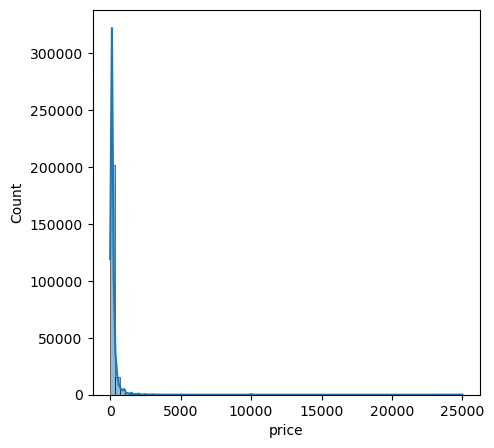

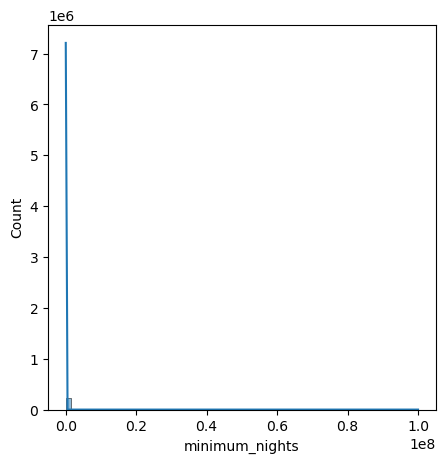

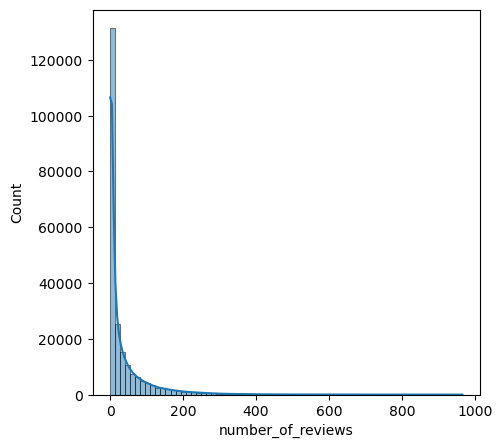

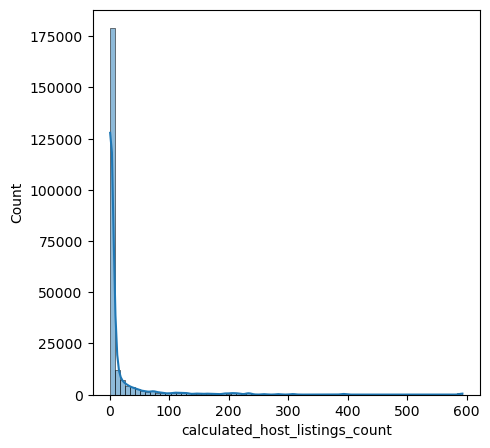

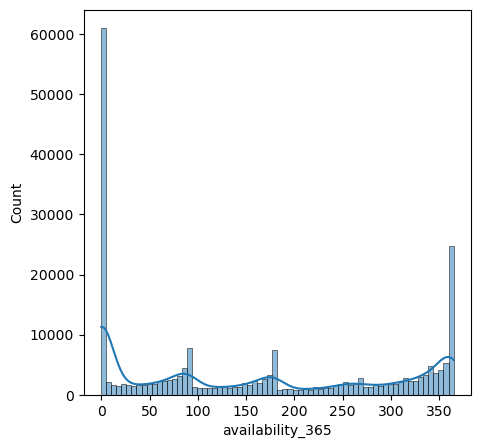

In [134]:
numeric = ['price',	'minimum_nights',	'number_of_reviews', 'calculated_host_listings_count', 'availability_365']

for n in numeric:
    plt.figure(figsize=(5,5))
    sns.histplot(Dataset[n], kde = True, bins=70)

Now after this we will check for the outliers using the box plots, as in Airbnb's case their are majority of budget homes whereas a few luxury homes as outliers.

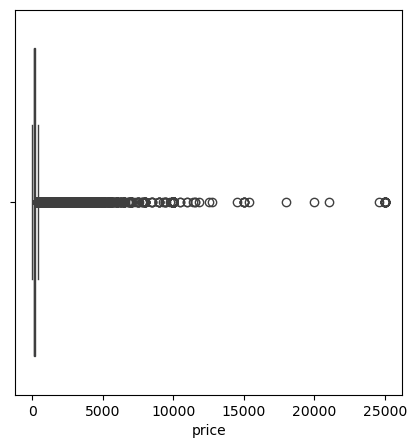

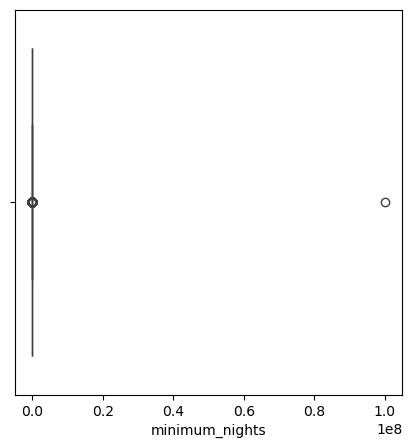

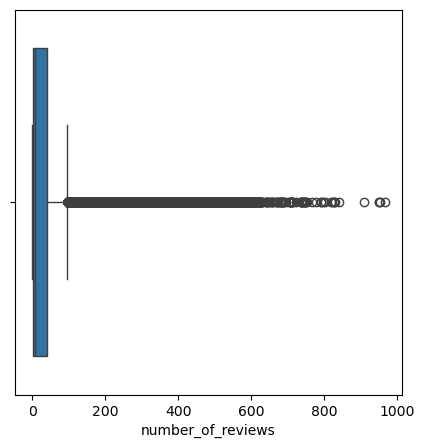

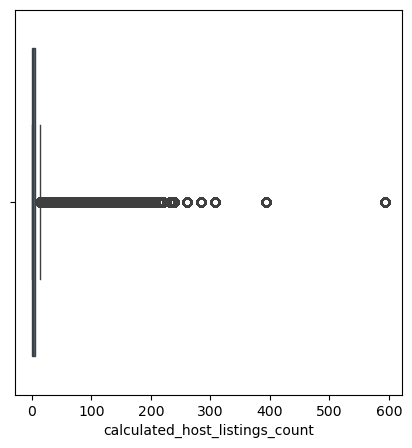

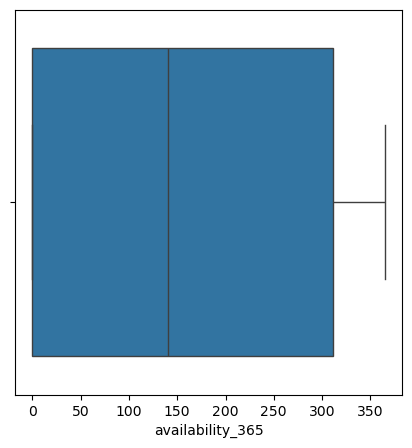

In [136]:
for plots in numeric:
    plt.figure(figsize=(5,5))
    sns.boxplot(x = Dataset[plots])

In [137]:
for cols in numeric:
    Dataset[f'log{cols}'] = np.log1p(Dataset[cols])

In [138]:
Dataset.columns

Index(['neighbourhood', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'calculated_host_listings_count',
       'availability_365', 'city', 'logprice', 'logminimum_nights',
       'lognumber_of_reviews', 'logcalculated_host_listings_count',
       'logavailability_365'],
      dtype='object')

Now I will be converting the numeric columns to log values in order to plot a better and much clearer picture which will somewhere have less or no outliers as compared to the numeric values.  

In [139]:
log_numeric = ['logprice', 'logminimum_nights',
       'lognumber_of_reviews', 'logcalculated_host_listings_count',
       'logavailability_365']

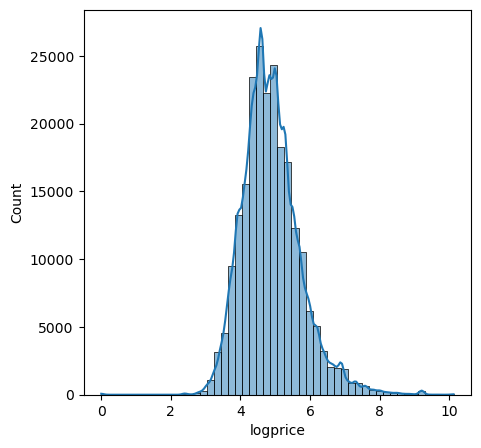

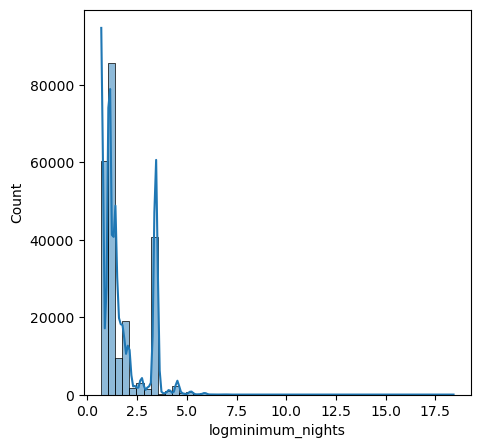

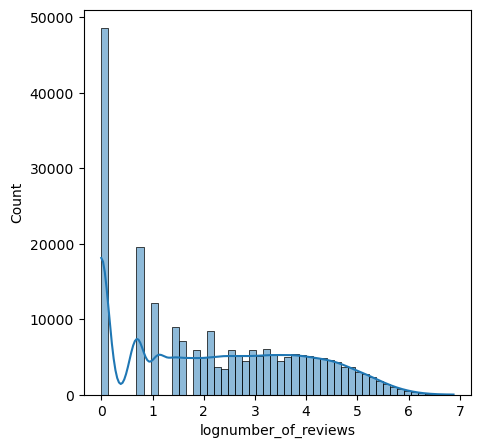

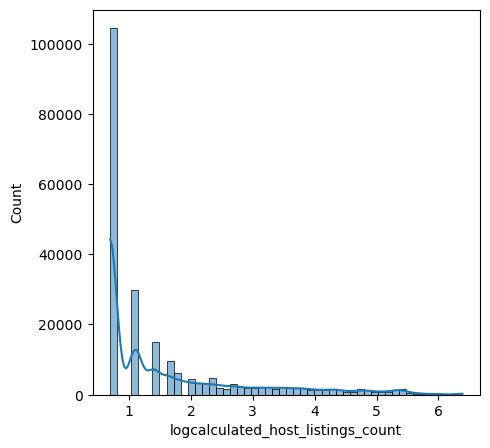

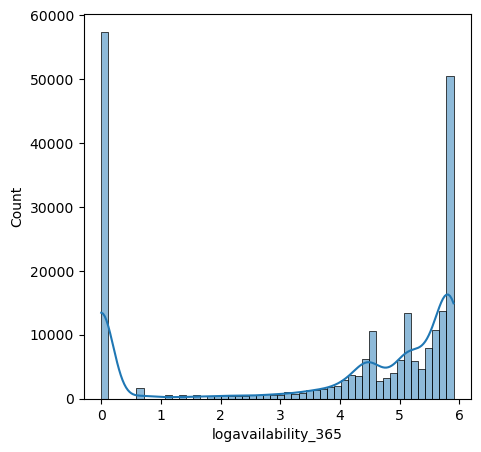

In [141]:
for n in log_numeric:
    plt.figure(figsize=(5,5))
    sns.histplot(Dataset[n], kde = True, bins=50)

Now this does gives me a better approach for the EDA and to see where is the data distributed. Further I am plotting a heat map to check for the correlation of these tables with the price

<Axes: >

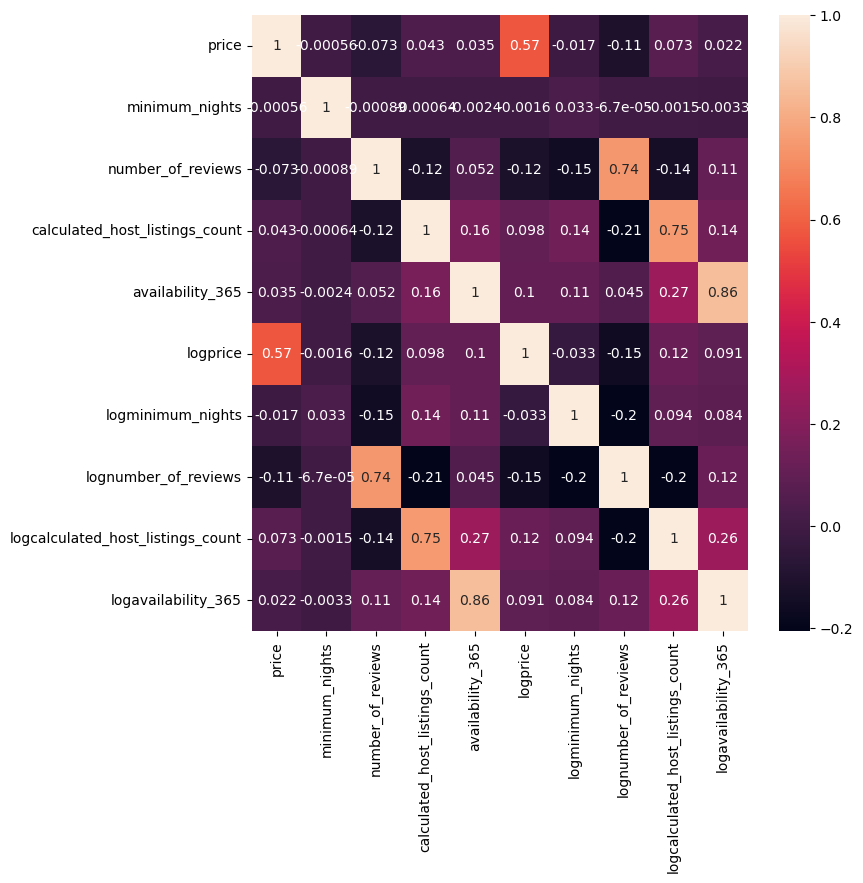

In [143]:
plt.figure(figsize = (8,8))
sns.heatmap(Dataset.corr(numeric_only = True), annot = True)

Now correlation heatmap shows that numeric features alone have a very weak correlation with respect to price. Host listings count has some tiny effect so as for the availabilty, but categorical features like room type and neighbourhood might dominate pricing. Therefore, to check if these categorical features have a price effect we need to encode them and this is a critical step for modeling.